# Hoja de Trabajo 2
Alina Carías, Daniel Machic y Ariela Mishaan

**Github:** https://github.com/ArielaMishaanCohen/HT2.git

## Task 1 - Análisis

Considere que usted estádiseñando el sistema de visión para un robot de almacén que debe moverse entre estanterías para recoger productos. El robot tiene dos cámaras frontales

**Pregunta 1: Durante una prueba, el robot gira sobre su propio eje para escanear el entorno. El ingeniero junior a tu cargo sugiere usar Homografías para medir la distancia a los objetos mientras el robot gira. ¿Es este un enfoque correcto? Justifiquesu respuesta utilizando los conceptos de C1, C2 y Paralaje.**

**No**, el enfoque correcto para medir distancia no es la homografía. Cuando el robot solo gira sobre su propio eje, ocurre lo siguiente: 

- El centro óptico de la cámara en el frame 1 (C1) y en el frame 2 (C2) es el mismo. 
- No hay traslación, solo rotación. 
- Como no hay cambio en la posición del centro de proyección, no existe paralaje.

La profundidad (Z) se puede estimar cuando existe paralaje, es decir, cuando un punto en el espacio cambia su posición relativa en la imagen debido a un cambio en el punto de vista (C1 ≠ C2). Pero en este caso, C1 = C2. Solo cambia la orientación. No hay desplazamiento lateral de los objetos dependiendo de su profundidad. Por lo tanto, no hay información suficiente para estimar distancia. 

Una homografía describe la relación entre imágenes cuando la escena es plana o la cámara solo rota. Pero la homografía no permite recuperar profundidad real de objetos en 3D, solo mapea correspondencias entre planos. 

**Conclusión:** el ingeniero junior está equivocado. Sin traslación no hay paralaje, y sin paralaje no se puede estimar distancia. 

**Si  el  robot  comienza  a  avanzar  (traslación)  y  detectas  que  la  disparidad  (d)  de  una  caja  aumenta repentinamente  entre el  frame  t  y el  frame  t+1,  ¿qué  puedes  inferir sobre  la  distancia  (Z) entre  el robot y la caja? ¿Qué riesgo industrial implicaría un error en el cálculo de esta disparidad?**

En visión estéreo:

$$Z = \frac{fB}{d}$$

Donde: 
- Z = profundidad
- f = distancia total
- B = baseline (distancia entre cámaras)
- d = disparidad

La profundidad es inversamente proporcional a la disparidad. Si la disparidad aumenta, entonces Z disminuye. 

Si entre el frame t y t+1 la disparidad de la caja aumenta repentinamente, esto significa que: 
- la caja está más cerca del robot
- el robot se está aproximando rápidamente al objeto

Si el sistema calcula mal la disparidad, podría estimar una distancia mayor a la real, el robot podría pensar que la caja está lejos y no frenaría a tiempo. El riesgo es que se podría dar colisión con estanterías, daño a mercadería, daño al robot y riesgo para los humanos de alrededor. 

## Task 2

Como director de proyectos, debe asegurar que los modelos de IA quepan en la memoria de los dispositivos (Edge  Computing). Por  ello,  tiene una  imagen  de  entrada  de  alta  resolución  proveniente  de  una  cámara industrial de 1280 x 720 píxeles. Se aplica una capa convolucional con los siguientes hiperparámetros

- Tamaño del Filtro (F): 5×5
- Padding (P): 2
- Stride (S): 2

**Utilizando la fórmula vista en clase, calcule las dimensiones ($W_{out}$,$H_{out}$) del Mapa de Características resultante. Muestra el procedimiento.**

Imagen de entrada:

$$W_{in} = 1280, H_{in} = 720$$

Hiperparámetros:
- Filtro F = 5
- Padding P = 2
- Stride S = 2

La fórmula para una convolución es:

$$W_{out} = \lfloor \frac{W_{in} - F + 2P}{S}\rfloor + 1$$

$$H_{out} = \lfloor \frac{H_{in} - F + 2P}{S}\rfloor + 1$$

**Para el ancho:**

$$W_{out} = \lfloor \frac{1280 - 5 + 2 \cdot 2}{2}\rfloor + 1$$

$$W_{out} = \lfloor \frac{1280 - 5 + 4}{2}\rfloor + 1$$

$$W_{out} = \lfloor \frac{1279}{2}\rfloor + 1$$

$$W_{out} = \lfloor 639.5\rfloor + 1 = 639 + 1 = \mathbf{640}$$

**Para la altura:**

$$H_{out} = \lfloor \frac{720 - 5 + 4}{2}\rfloor + 1$$

$$H_{out} = \lfloor \frac{719}{2}\rfloor + 1$$

$$H_{out} = \lfloor 359.5\rfloor + 1 = 359 + 1 = \mathbf{360}$$

**Dimensiones finales del feature map:** 

$$W_{out}, H_{out} = (640, 360)$$

**¿Qué  sucedería  con  el  tamaño  de  la  salida  si  decides  cambiar  el  Padding  a  P=0  (Valid  Padding)? ¿Cómo afectaría esto a la información de los bordes de la imagen (donde suelen estar las referencias de las paredes del almacén)?**

Si cambiamos el Padding a 0: 

**Para el ancho:**

$$W_{out} = \lfloor \frac{1280 - 5 + 0}{2}\rfloor + 1$$

$$W_{out} = \lfloor \frac{1275}{2}\rfloor + 1$$

$$W_{out} = \lfloor 637.5\rfloor + 1 = 637 + 1 = \mathbf{638}$$

**Para la altura:**

$$H_{out} = \lfloor \frac{720 - 5 + 0}{2}\rfloor + 1$$

$$H_{out} = \lfloor \frac{715}{2}\rfloor + 1$$

$$H_{out} = \lfloor 357.5\rfloor + 1 = 357 + 1 = \mathbf{358}$$

**Dimensiones finales del feature map:** 

$$W_{out}, H_{out} = (638, 358)$$

Se puede ver que si el Padding es 0, el kernel no se aplica en los bordes exteriores, eso implica que se pierden los pixeles de alrededor de la imagen y se elimina la información de las orillas. En el contexto del almacén, como las paredes suelen estar en los extremos del campo visual, las referencias de las estructuras (como líneas verticales o esquinas) pueden perderse. El sistema podría detectar peor los límites del pasillo. 

## Task 3

**1. Usted está desarrollando un sistema de detección de griestas microscópicas en motores de avión. ¿Qué combinación de Stride y Pooling recomendaría para no perder detalles críticos en las primeras capas de la red? Justifique técnicamente**

Recomendación: Stride = 1, sin Max Pooling en las primeras capas. 

Una grieta miscroscópica puede ocupar, lo más, 2-3 píceles. Si se usa stride = 2 desde el inicio, el filtro salta píxeles y puede perderse exactamente donde está la grieta. Con stride = 1 el filtro recorre cada píxel sin saltar nada. 

El pooling, en las primeras capas conviene usar Average Pooling o directamente no usar pooling. El Max Pooling descarta todo excepto el valor más alto de una región, lo que puede romper la continuidad de una estructura lineal como una grieta. El Average Pooling suaviza sin tirar información tan agresivamente. 

En capas más profundas ya se puede ser más agresivo, porque para ese punto la red ya estrajo los patrones relevantes. 

**2. Un cliente le pide que el sistema funcione en un procesador muy limitado (como una cámara inteligente con poca RAM). Explique cómo podrías utilizar el Stride y Max Pooling estratégicamente para reducir la carfa computacional sin eliminar las características más fuertes (activaciones) del Mapa de Características.**

Recomendación: Stride = 2 + Max Pooling desde capas tempranas

El problema con poca RAM es que los feature maps consumen mucha memoria. Con stride = 2 el feature ma´se reduce a la cuarta parte del tamaño original, lo que baja el consumo drásticamente. 

El Max Pooling es la elección correcta porque aunque reduce el tamaño, conserva las activaciones más fuertes de cada región. Las características importantes (brodes, texturas destacadas) generan activaciones altas que sobreviven al MaxPool, así que no se pierde la información más relevante, solo se descarta lo débil. 

El tradeoff es que se pierde la precisión espacial (no se sabe dónde está exactamente algo), pero para un sistema de detección simple eso es aceptable. 

## Task 4

In [7]:
import numpy as np

def manual_convolution(image, kernel, stride=1, padding=0):
    """ Realiza la convolución manual de una imagen 2D en escala de grises.

    Parámetros:
        image  : matriz 2D (H x W)
        kernel : matriz 2D (N x N)
        stride : paso del desplazamiento
        padding: cantidad de zero-padding

    Retorna: feature_map : matriz resultante después de la convolución """

    # Dimensiones originales
    H, W = image.shape
    N = kernel.shape[0]  # Se asume kernel cuadrado

    # Aplicar Zero Padding
    if padding > 0:
        padded_image = np.pad(image, 
                              ((padding, padding), (padding, padding)), 
                              mode='constant', 
                              constant_values=0)
    else:
        padded_image = image

    H_p, W_p = padded_image.shape

    # Calcular dimensiones de salida
    H_out = int((H_p - N) / stride) + 1
    W_out = int((W_p - N) / stride) + 1

    # Inicializar Feature Map
    feature_map = np.zeros((H_out, W_out))

    # Recorrer imagen aplicando producto punto
    for i in range(H_out):
        for j in range(W_out):
            # Coordenadas de la ventana actual
            start_i = i * stride
            start_j = j * stride
            end_i = start_i + N
            end_j = start_j + N

            # Extraer región
            region = padded_image[start_i:end_i, start_j:end_j]

            # Producto punto (suma de multiplicaciones elemento a elemento)
            feature_map[i, j] = np.sum(region * kernel)

    return feature_map

### Prueba de validación

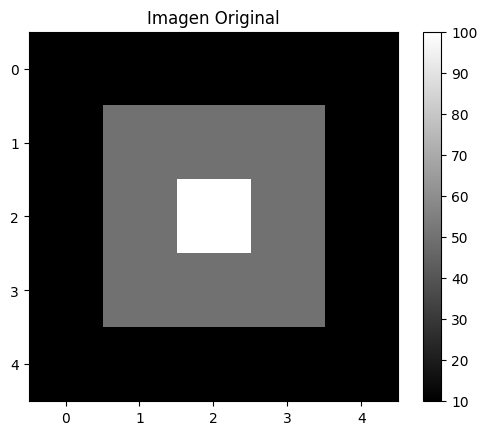

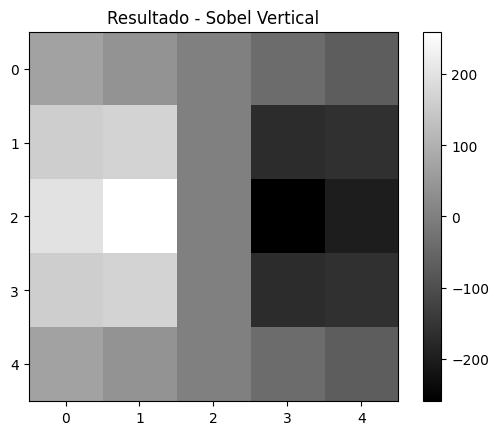

In [ ]:
import matplotlib.pyplot as plt

# Imagen 5x5 en escala de grises
image = np.array([
    [10, 10, 10, 10, 10],
    [10, 50, 50, 50, 10],
    [10, 50,100, 50, 10],
    [10, 50, 50, 50, 10],
    [10, 10, 10, 10, 10]
])

# Filtro Sobel vertical
sobel_vertical = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

# Aplicar convolución manual
result = manual_convolution(image, sobel_vertical, stride=1, padding=1)

# Imagen original
plt.figure()
plt.title("Imagen Original")
plt.imshow(image, cmap='gray')
plt.colorbar()
plt.show()

# Imagen resultante (Feature Map)
plt.figure()
plt.title("Resultado - Sobel Vertical")
plt.imshow(result, cmap='gray')
plt.colorbar()
plt.show()

### **¿Cómo afecta el desplazamiento del kernel al tamaño de salida?**
La validación del Feature Map depende de:
$$H_{out}=\left[ \frac{H_{in}-N+2P}{S} \right]+1$$
$$W_{out}=\left[ \frac{W_{in}-N+2P}{S} \right]+1$$

Donde:
- N = tamaño del kernel
- P = padding
- S = stride

**Caso 1: Stride = 1**

El kernel se mueve píxel por píxel.
- Mayor resolución espacial
- Feature map más grande
- Mayor costo computacional

**Caso 2: Stride = 2**

El kernel salta posiciones.
- Reduce el tamaño aproximadamente a la mitad en cada dimensión
- Menor consumo de memoria
- Menor precisión espacial

**Efecto del Padding**
- Padding = 0 → se pierden bordes
- Padding > 0 → se preserva información periférica


En este caso se utilizó:
- Imagen: 5×5
- Kernel: 3×3 (Sobel)
- Padding: 1
- Stride: 1

Aplicando la fórmula:
$$H_{out}=\left[ \frac{5-3+2(1)}{1} \right]+1=5$$
$$W_{out}=\left[ \frac{5-3+2(1)}{S} \right]+1=5$$

Por ello, el Feature Map mantiene dimensión 5×5.

Si el stride fuera 2, el tamaño disminuiría.


El kernel funciona como una ventana deslizante:
1. Se posiciona sobre una región N×N.
2.	Se multiplican elemento a elemento imagen × kernel.
3.	Se suman los resultados.
4.	Se guarda el valor en el feature map.
5.	Se desplaza según el stride.
6.	Se repite hasta cubrir toda la imagen.

El stride controla cuántas posiciones avanza el kernel en cada paso.
Mientras mayor el stride → menor el tamaño de salida.

Esta implementación replica la operación fundamental que realizan las capas convolucionales en frameworks como PyTorch o TensorFlow, permitiendo comprender cómo el stride y el padding afectan directamente la dimensionalidad y la preservación de información espacial.